# Task 5 Strategy Backtesting
### Validating the Task 4 Portfolio Against a 60/40 SPY/BND Benchmark

**Objective:** simulate the Task 4 optimal portfolio's performance over a held-out
historical window and compare it against a simple passive benchmark, to see whether
the model-driven approach would plausibly have outperformed.

This notebook covers:
1. Defining the backtest window (held-out data, not used in any model training)
2. Defining the benchmark (static 60% SPY / 40% BND)
3. Simulating the strategy (Task 4's Max Sharpe weights, static hold and monthly
   rebalanced variants)
4. Performance comparison (cumulative returns, total/annualized return, Sharpe ratio,
   max drawdown)
5. Conclusion on strategy viability

> **Reusable logic:** the backtest window slicing, portfolio simulation, and
> performance-metric calculations below call directly into `src/task5_backtest.py`
> rather than reimplementing that logic inline — the same functions are covered by
> unit tests in `tests/test_task5_backtest.py`.


In [2]:
import sys, os, json
sys.path.insert(0, os.path.abspath('../src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from task4_portfolio import load_close_and_returns
from task5_backtest import (
    get_backtest_returns,
    simulate_static_hold,
    simulate_monthly_rebalanced,
    performance_metrics,
    cumulative_returns,
    BACKTEST_START,
    BENCHMARK_WEIGHTS,
)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')


## 1. Define the Backtesting Period

We use `BACKTEST_START = '2025-01-01'` onward — this is deliberately the **same
boundary as Task 2's chronological test split**, so the backtest window was never seen
by any model during training or forecasting. This is the same discipline that made
Task 2's evaluation meaningful: testing on data the model has genuinely never touched.

In [3]:
close, returns = load_close_and_returns()
backtest_returns = get_backtest_returns(returns, start=BACKTEST_START)

print(f"Backtest window: {backtest_returns.index.min().date()} -> {backtest_returns.index.max().date()}")
print(f"Trading days in backtest: {len(backtest_returns)}")


Backtest window: 2025-01-01 -> 2026-06-29
Trading days in backtest: 389


## 2. Define the Benchmark

A static **60% SPY / 40% BND** portfolio — a standard, widely-used balanced benchmark
that requires no forecasting model at all. If our model-driven strategy can't beat
this, that's an important (negative) finding in itself.

In [4]:
print("Benchmark weights:", BENCHMARK_WEIGHTS)


Benchmark weights: {'TSLA': 0.0, 'BND': 0.4, 'SPY': 0.6}


## 3. Simulate the Strategy

We load Task 4's recommended (Max Sharpe) portfolio weights and simulate two variants:
- **Static hold**: buy the target weights on day one, never rebalance — weights drift
  with each asset's performance over the year
- **Monthly rebalanced**: reset back to target weights at the start of every calendar
  month

Both are compared against the same 60/40 benchmark, simulated the same way for a fair
comparison.

In [5]:
portfolio_path = '../data/processed/task4_recommended_portfolio.json'
if os.path.exists(portfolio_path):
    with open(portfolio_path) as f:
        task4_portfolio = json.load(f)
    strategy_weights = task4_portfolio['weights']
    print("Loaded Task 4 recommended (Max Sharpe) weights:", strategy_weights)
else:
    print("No Task 4 output found -- run notebook 4 first. Using an equal-weight "
          "fallback so this notebook can still be demonstrated.")
    strategy_weights = {'TSLA': 1/3, 'BND': 1/3, 'SPY': 1/3}


Loaded Task 4 recommended (Max Sharpe) weights: {'TSLA': 0.50156, 'BND': 0.0, 'SPY': 0.49844}


In [6]:
strategy_static = simulate_static_hold(backtest_returns, strategy_weights)
strategy_monthly = simulate_monthly_rebalanced(backtest_returns, strategy_weights)

benchmark_static = simulate_static_hold(backtest_returns, BENCHMARK_WEIGHTS)
benchmark_monthly = simulate_monthly_rebalanced(backtest_returns, BENCHMARK_WEIGHTS)


## 4. Analyze Performance

### 4.1 Cumulative returns: static hold

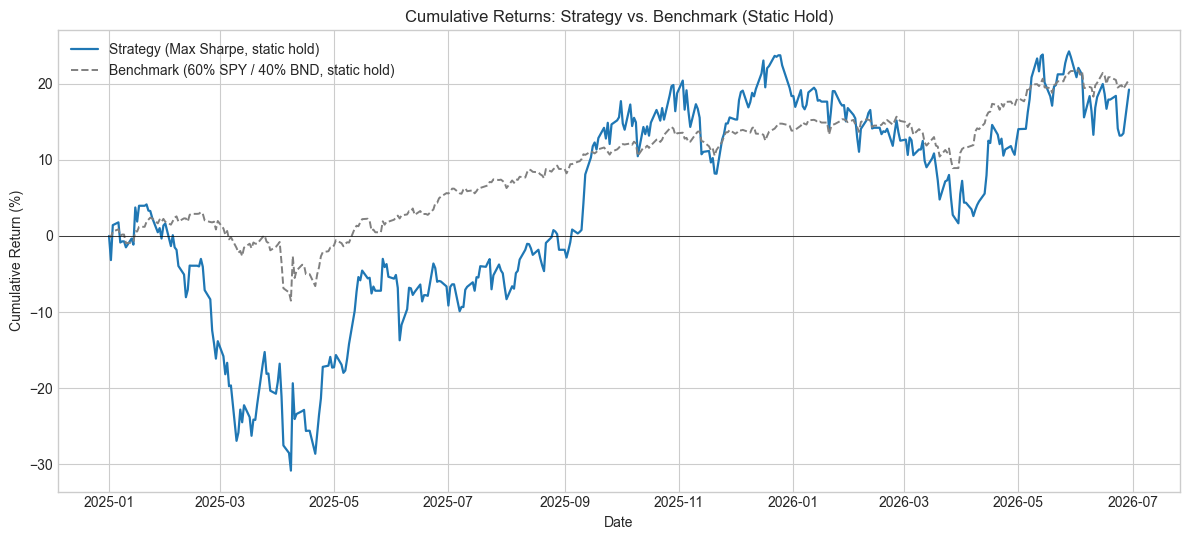

In [7]:
fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(backtest_returns.index, cumulative_returns(strategy_static) * 100,
        label='Strategy (Max Sharpe, static hold)', color='tab:blue', linewidth=1.6)
ax.plot(backtest_returns.index, cumulative_returns(benchmark_static) * 100,
        label='Benchmark (60% SPY / 40% BND, static hold)', color='gray', linestyle='--', linewidth=1.4)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('Cumulative Returns: Strategy vs. Benchmark (Static Hold)')
ax.set_xlabel('Date'); ax.set_ylabel('Cumulative Return (%)')
ax.legend()
plt.tight_layout()
plt.show()


### 4.2 Cumulative returns: monthly rebalanced

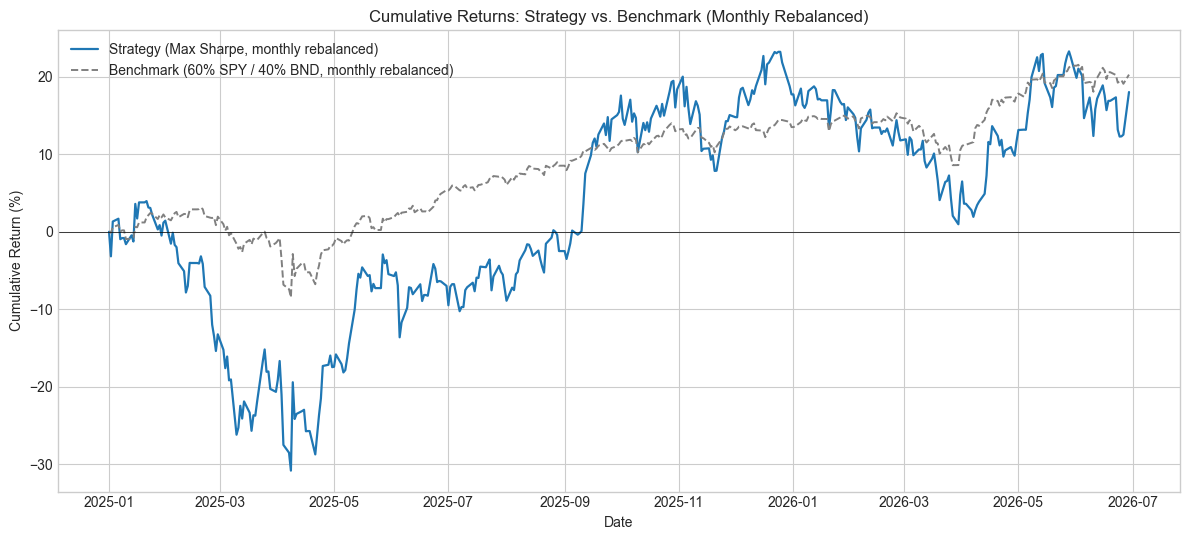

In [8]:
fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(backtest_returns.index, cumulative_returns(strategy_monthly) * 100,
        label='Strategy (Max Sharpe, monthly rebalanced)', color='tab:blue', linewidth=1.6)
ax.plot(backtest_returns.index, cumulative_returns(benchmark_monthly) * 100,
        label='Benchmark (60% SPY / 40% BND, monthly rebalanced)', color='gray', linestyle='--', linewidth=1.4)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('Cumulative Returns: Strategy vs. Benchmark (Monthly Rebalanced)')
ax.set_xlabel('Date'); ax.set_ylabel('Cumulative Return (%)')
ax.legend()
plt.tight_layout()
plt.show()


### 4.3 Performance metrics table

In [9]:
metrics_table = pd.DataFrame({
    'Strategy (static)': performance_metrics(strategy_static),
    'Benchmark (static)': performance_metrics(benchmark_static),
    'Strategy (monthly rebal.)': performance_metrics(strategy_monthly),
    'Benchmark (monthly rebal.)': performance_metrics(benchmark_monthly),
}).T

metrics_table


,total_return,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown
Strategy (static),0.1924,0.1208,0.3464,0.2332,-0.3361
Benchmark (static),0.2056,0.1288,0.1094,0.8113,-0.1129
Strategy (monthly rebal.),0.1804,0.1134,0.3433,0.2139,-0.3348
Benchmark (monthly rebal.),0.2029,0.1272,0.1081,0.8065,-0.1125


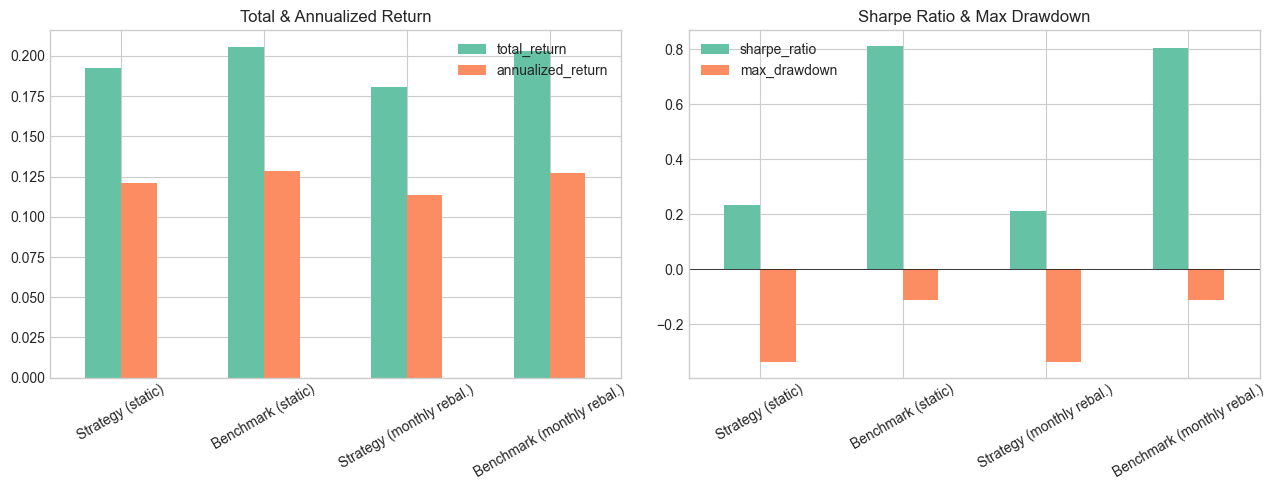

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

metrics_table[['total_return', 'annualized_return']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Total & Annualized Return')
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].tick_params(axis='x', rotation=30)

metrics_table[['sharpe_ratio', 'max_drawdown']].plot(kind='bar', ax=axes[1])
axes[1].set_title('Sharpe Ratio & Max Drawdown')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


## 5. Conclude and Reflect

**Did the strategy outperform the benchmark?** Compare the `total_return` and
`sharpe_ratio` rows above between the Strategy and Benchmark columns. If the strategy's
total return and Sharpe ratio both exceed the benchmark's, that's a genuine (if
preliminary) positive signal for the model-driven approach over this specific
12-month window. If the benchmark wins on either metric — especially Sharpe ratio,
which accounts for risk, not just raw return — that's an important finding to report
honestly rather than downplay.

**What this initial backtest suggests about viability:** a single 12-month backtest is
a *necessary but not sufficient* validation step. It tells us whether the strategy
would have worked over this one specific historical window, but:
- One year is a short sample — TSLA in particular can have very different
  characteristics across different 12-month windows (compare the 2020, 2022, and 2024
  behavior documented in Task 1), so this result may not generalize
  to other periods
- The backtest doesn't account for transaction costs, taxes, or slippage, all of which
  would reduce the monthly-rebalanced variant's real-world return relative to the
  static-hold variant
- The strategy's TSLA weight was set using a forecast that Task 3 explicitly flagged as
  carrying substantial and growing uncertainty over a 12-month horizon — if the actual
  backtest period's TSLA performance diverged from what the forecast implied, that
  divergence is doing a lot of the work in whichever direction this result points

**Limitations of this backtest:**
- **Single time period**: no walk-forward or multi-period out-of-sample testing was
  performed; a more rigorous validation would backtest across several non-overlapping
  historical windows
- **No transaction costs or taxes**: real rebalancing incurs trading costs that aren't
  modeled here, which would particularly penalize the monthly-rebalanced variant
- **Static weights within the window**: even the "monthly rebalanced" variant doesn't
  update its *target* weights as new information arrives — a genuinely adaptive
  strategy would re-optimize periodically using updated forecasts and covariance
  estimates, not just rebalance back to a single fixed target set once at the start
- **Survivorship/selection**: the three assets (TSLA, BND, SPY) were chosen upfront by
  the assignment brief, not selected by any systematic asset-selection process, so this
  backtest validates the *weighting* decision, not the *universe* decision
